# GIS Inclusion Survey Analysis

grouped indices, descriptive statistics, reliability checks, pre/post comparisons, demographic summaries, open-ended response themes and visuals

In [44]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

DATA_PATH = Path('gis_survey_cleaned.xlsx')
OUT_DIR = Path('gis_survey_outputs')
FIG_DIR = OUT_DIR / 'figures'
TABLE_DIR = OUT_DIR / 'tables'
EXCEL_PATH = TABLE_DIR / 'survey_analysis_tables.xlsx'

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def save_table_to_excel(table, sheet_name):
    with pd.ExcelWriter(EXCEL_PATH, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        table.to_excel(writer, sheet_name=sheet_name, index=False)


## data cleaning

In [46]:
df_raw = pd.read_excel(DATA_PATH)

#date
df = df_raw.copy()
df['StartDate'] = pd.to_datetime(df['StartDate'], errors='coerce')
df['EndDate'] = pd.to_datetime(df['EndDate'], errors='coerce')
df = df[df['StartDate'].notna()].copy()

df['survey_month'] = df['StartDate'].dt.month
df['period'] = np.where(df['survey_month'] == 6, 'Before',
                        np.where(df['survey_month'] == 12, 'After', 'Other'))

df = df[df['period'].isin(['Before', 'After'])].copy()

len(df_raw)
len(df)
display(df['period'].value_counts().rename_axis('period').reset_index(name='n'))

C:\Users\snigd\AppData\Local\Temp\ipykernel_6444\3421016971.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['StartDate'] = pd.to_datetime(df['StartDate'], errors='coerce')
C:\Users\snigd\AppData\Local\Temp\ipykernel_6444\3421016971.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['EndDate'] = pd.to_datetime(df['EndDate'], errors='coerce')


,period,n
0,After,22
1,Before,8


## groups for indices

In [47]:
indices = {
    'Curriculum Representation': ['Q2.2', 'Q2.3', 'Q2.4', 'Q2.5'],
    'Inclusive Case Studies': ['Q3.2', 'Q3.3', 'Q3.5', 'Q3.6', 'Q3.7'],
    'Inclusive Course Materials': ['Q4.2', 'Q4.3', 'Q4.4', 'Q4.5'],
    'Inclusive Teaching Activities': ['Q5.3', 'Q5.4', 'Q5.5', 'Q5.6'],
    'Responsible Spatial Practice': ['Q2.7', 'Q5.7']
}

demographic_cols = ['Q1.3', 'Q1.4', 'Q1.5', 'Q1.6']
technical_cols = ['Q1.7', 'Q1.8']
awareness_cols = ['Q1.9', 'Q1.10']
open_ended_cols = ['Q6.2', 'Q6.3', 'Q6.4']

for name, cols in indices.items():
    print(f'{name}: {cols}')

Curriculum Representation: ['Q2.2', 'Q2.3', 'Q2.4', 'Q2.5']
Inclusive Case Studies: ['Q3.2', 'Q3.3', 'Q3.5', 'Q3.6', 'Q3.7']
Inclusive Course Materials: ['Q4.2', 'Q4.3', 'Q4.4', 'Q4.5']
Inclusive Teaching Activities: ['Q5.3', 'Q5.4', 'Q5.5', 'Q5.6']
Responsible Spatial Practice: ['Q2.7', 'Q5.7']


## survey responses to numeric scores

converted to a 1–5 scale -- higher values mean stronger agreement, better representation or stronger inclusion

In [48]:
likert_map = {

    'No': 1,
    'Very less': 1,
    'Less': 2,
    'Maybe': 3,
    'Moderate': 3,
    'Very well': 4,
    'Extreamly well': 5, 
    'Extremely well': 5,
    'Not well at all': 1,
    'Slightly well': 2,
    'Moderately well': 3,
    'Very less': 1,
    'Less': 2,
    'Somewhat improved': 4,
    'Significantly improved': 5,
}

num = df.copy()

cols_to_score = sorted(set(sum(indices.values(), []) + technical_cols + awareness_cols))
for col in cols_to_score:
    num[col + '_score'] = num[col].map(likert_map)

for col in cols_to_score:
    missing = num.loc[num[col].notna() & num[col + '_score'].isna(), col].unique()
    if len(missing) > 0:
        print(f'Unmapped values in {col}: {missing}')

## index scores

In [49]:
for index_name, cols in indices.items():
    score_cols = [c + '_score' for c in cols]
    num[index_name] = num[score_cols].mean(axis=1)

index_names = list(indices.keys())

num['Overall Inclusive GIS Curriculum Score'] = num[index_names].mean(axis=1)

display(num[['period'] + index_names + ['Overall Inclusive GIS Curriculum Score']].head())

,period,Curriculum Representation,Inclusive Case Studies,Inclusive Course Materials,Inclusive Teaching Activities,Responsible Spatial Practice,Overall Inclusive GIS Curriculum Score
1,Before,4.00,4.0,4.00,5.00,3.5,4.10
2,Before,3.50,3.2,3.25,4.25,3.5,3.54
3,Before,3.25,2.6,2.00,4.50,4.0,3.27
4,Before,4.00,3.8,3.75,4.50,3.5,3.91
5,Before,2.25,1.8,2.00,3.50,4.0,2.71


## participant characteristics 

for introducing the survey (??)

In [50]:
def count_percent_table(data, col, label):
    out = data[col].value_counts(dropna=False).reset_index()
    out.columns = [label, 'n']
    out['percent'] = (out['n'] / len(data) * 100).round(1)
    return out

participant_tables = {}
for col, label in zip(demographic_cols, ['Academic background', 'Gender', 'Program year', 'Student status']):
    participant_tables[label] = count_percent_table(df, col, label)
    display(participant_tables[label])

for label, table in participant_tables.items():
    safe = label.lower().replace(' ', '_')
    table.to_csv(TABLE_DIR / f'{safe}.csv', index=False)

,Academic background,n,percent
0,Other,12,40.0
1,Engineering,11,36.7
2,Urban Planning,4,13.3
3,Social Science,3,10.0


,Gender,n,percent
0,Female,16,53.3
1,Male,14,46.7


,Program year,n,percent
0,1st year,22,73.3
1,2nd year,7,23.3
2,Other,1,3.3


,Student status,n,percent
0,International,22,73.3
1,Domestic,8,26.7


## cronbach's alpha

to check whether the questions in each index behave like they are measuring the same construct

In [51]:
def cronbach_alpha(dataframe):
    """Calculate Cronbach's alpha for a set of numeric survey items."""
    x = dataframe.dropna()
    if x.shape[0] < 2 or x.shape[1] < 2:
        return np.nan
    item_variances = x.var(axis=0, ddof=1)
    total_variance = x.sum(axis=1).var(ddof=1)
    n_items = x.shape[1]
    if total_variance == 0:
        return np.nan
    return (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_variance)

alpha_rows = []
for index_name, cols in indices.items():
    score_cols = [c + '_score' for c in cols]
    alpha_rows.append({
        'Index': index_name,
        'Questions': ', '.join(cols),
        'Number of items': len(cols),
        "Cronbach's alpha": round(cronbach_alpha(num[score_cols]), 3)
    })

alpha_table = pd.DataFrame(alpha_rows)
display(alpha_table)
alpha_table.to_csv(TABLE_DIR / 'cronbach_alpha_by_index.csv', index=False)

,Index,Questions,Number of items,Cronbach's alpha
0,Curriculum Representation,"Q2.2, Q2.3, Q2.4, Q2.5",4,0.861
1,Inclusive Case Studies,"Q3.2, Q3.3, Q3.5, Q3.6, Q3.7",5,0.843
2,Inclusive Course Materials,"Q4.2, Q4.3, Q4.4, Q4.5",4,0.681
3,Inclusive Teaching Activities,"Q5.3, Q5.4, Q5.5, Q5.6",4,0.774
4,Responsible Spatial Practice,"Q2.7, Q5.7",2,0.409


## descriptive statistics (for each index)

before/after mean, standard deviation and sample size for each index

In [53]:
desc_rows = []
for index_name in index_names + ['Overall Inclusive GIS Curriculum Score']:
    for period in ['Before', 'After']:
        values = num.loc[num['period'] == period, index_name].dropna()
        desc_rows.append({
            'Index': index_name,
            'Period': period,
            'n': len(values),
            'Mean': round(values.mean(), 3),
            'SD': round(values.std(ddof=1), 3),
            'Median': round(values.median(), 3),
            'Min': round(values.min(), 3),
            'Max': round(values.max(), 3)
        })

desc_table = pd.DataFrame(desc_rows)
display(desc_table)
save_table_to_excel(desc_table, 'descriptive_statistics_by_index')

,Index,Period,n,Mean,SD,Median,Min,Max
0,Curriculum Representation,Before,8,3.469,0.619,3.625,2.25,4.00
1,Curriculum Representation,After,22,3.023,0.736,3.125,1.50,4.00
2,Inclusive Case Studies,Before,8,3.300,0.763,3.500,1.80,4.00
3,Inclusive Case Studies,After,22,3.036,0.564,3.100,2.00,3.80
4,Inclusive Course Materials,Before,8,3.250,0.824,3.500,2.00,4.00
5,Inclusive Course Materials,After,22,2.943,0.475,3.000,2.00,3.75
6,Inclusive Teaching Activities,Before,7,4.393,0.476,4.500,3.50,5.00
7,Inclusive Teaching Activities,After,22,3.500,0.641,3.500,2.00,4.75
8,Responsible Spatial Practice,Before,8,3.750,0.463,3.750,3.00,4.50
9,Responsible Spatial Practice,After,22,3.682,0.646,4.000,2.50,4.50


## statistical comparisons

since they are diff cohorts, used the Mann–Whitney U test. Also reported Cohen's d as a simple effect size for the mean difference

In [54]:
from scipy.stats import mannwhitneyu

In [55]:
def cohens_d(x, y):
    # Cohen's d for two independent groups
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    pooled_sd = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    if pooled_sd == 0:
        return np.nan
    return (y.mean() - x.mean()) / pooled_sd

comparison_rows = []
for index_name in index_names + ['Overall Inclusive GIS Curriculum Score']:
    before = num.loc[num['period'] == 'Before', index_name].dropna()
    after = num.loc[num['period'] == 'After', index_name].dropna()
    
    if len(before) > 0 and len(after) > 0:
        u_stat, p_value = mannwhitneyu(before, after, alternative='two-sided')
        d = cohens_d(before, after)
        comparison_rows.append({
            'Index': index_name,
            'Before Mean': round(before.mean(), 3),
            'After Mean': round(after.mean(), 3),
            'Difference': round(after.mean() - before.mean(), 3),
            'Percent Change': round(((after.mean() - before.mean()) / before.mean()) * 100, 1) if before.mean() != 0 else np.nan,
            'Mann-Whitney U': round(u_stat, 3),
            'p-value': round(p_value, 4),
            "Cohen's d": round(d, 3)
        })

comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table)
save_table_to_excel(comparison_table, 'pre_post_comparisons')

,Index,Before Mean,After Mean,Difference,Percent Change,Mann-Whitney U,p-value,Cohen's d
0,Curriculum Representation,3.469,3.023,-0.446,-12.9,121.0,0.1238,-0.630
1,Inclusive Case Studies,3.300,3.036,-0.264,-8.0,115.5,0.2019,-0.425
2,Inclusive Course Materials,3.250,2.943,-0.307,-9.4,119.0,0.1495,-0.527
3,Inclusive Teaching Activities,4.393,3.500,-0.893,-20.3,136.5,0.0024,-1.468
4,Responsible Spatial Practice,3.750,3.682,-0.068,-1.8,88.5,1.0000,-0.113
5,Overall Inclusive GIS Curriculum Score,3.622,3.237,-0.386,-10.6,129.0,0.0575,-0.769


## grouped index comparison

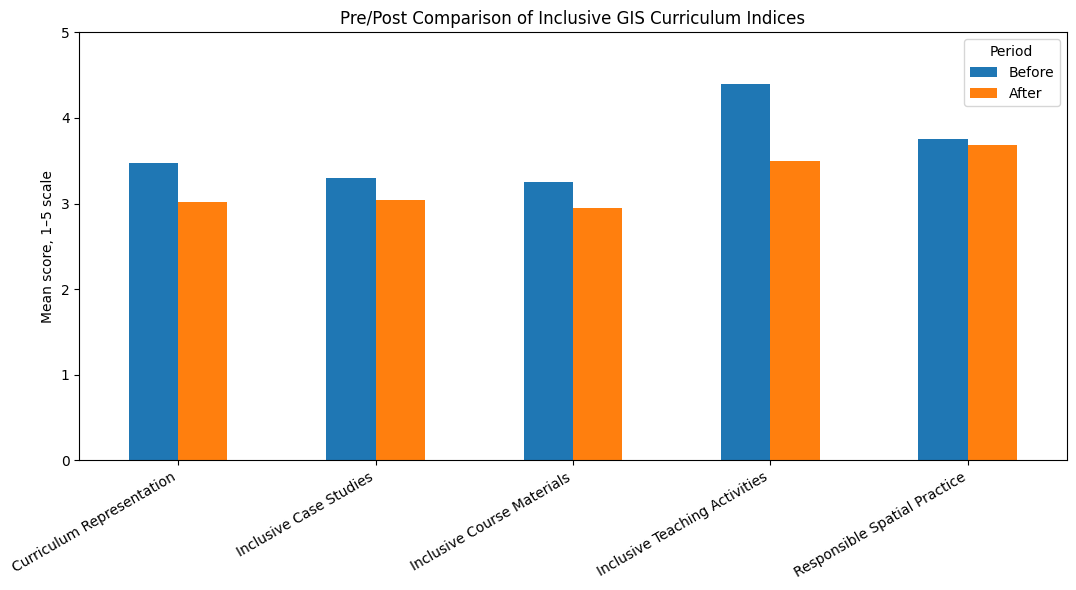

In [56]:
plot_data = desc_table[desc_table['Index'].isin(index_names)].pivot(index='Index', columns='Period', values='Mean')
plot_data = plot_data[['Before', 'After']]

ax = plot_data.plot(kind='bar', figsize=(11, 6))
ax.set_title('Pre/Post Comparison of Inclusive GIS Curriculum Indices')
ax.set_ylabel('Mean score, 1–5 scale')
ax.set_xlabel('')
ax.set_ylim(0, 5)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Period')
plt.tight_layout()

plt.savefig(FIG_DIR / 'index_comparison_grouped_bar.png', dpi=300, bbox_inches='tight')
plt.show()

## heatmap of index means

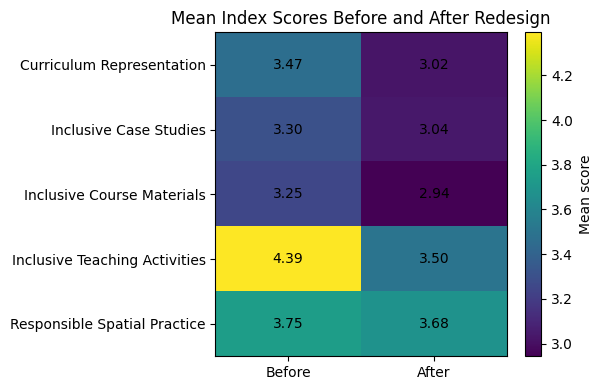

In [57]:
heat = plot_data.copy()

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(heat.values, aspect='auto')

ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title('Mean Index Scores Before and After Redesign')

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f'{heat.iloc[i, j]:.2f}', ha='center', va='center')

fig.colorbar(im, ax=ax, label='Mean score')
plt.tight_layout()
plt.savefig(FIG_DIR / 'index_mean_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## overall inclusive curriculum score

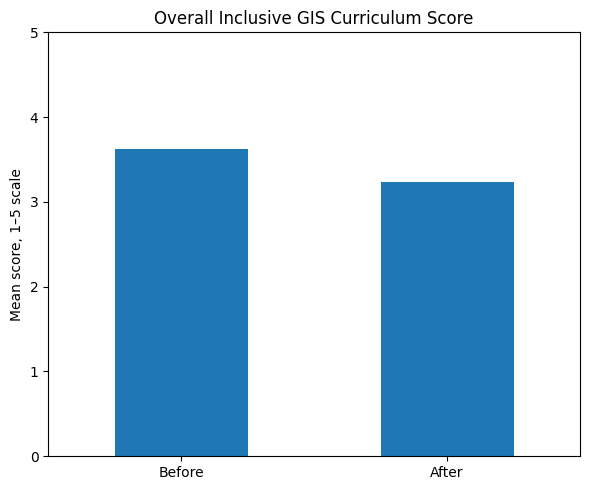

In [58]:
overall = desc_table[desc_table['Index'] == 'Overall Inclusive GIS Curriculum Score'].set_index('Period').loc[['Before', 'After']]

ax = overall['Mean'].plot(kind='bar', figsize=(6, 5))
ax.set_title('Overall Inclusive GIS Curriculum Score')
ax.set_ylabel('Mean score, 1–5 scale')
ax.set_xlabel('')
ax.set_ylim(0, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'overall_inclusive_curriculum_score.png', dpi=300, bbox_inches='tight')
plt.show()

## Technical learning before and after the course

to emphasize that technical learning has not been affected by the curriculum change

,Measure,Period,n,Mean,SD
0,GIS background before course,Before,8,2.000,1.195
1,GIS background before course,After,22,1.818,1.097
2,GIS background after course,Before,8,4.875,0.354
3,GIS background after course,After,22,4.682,0.477


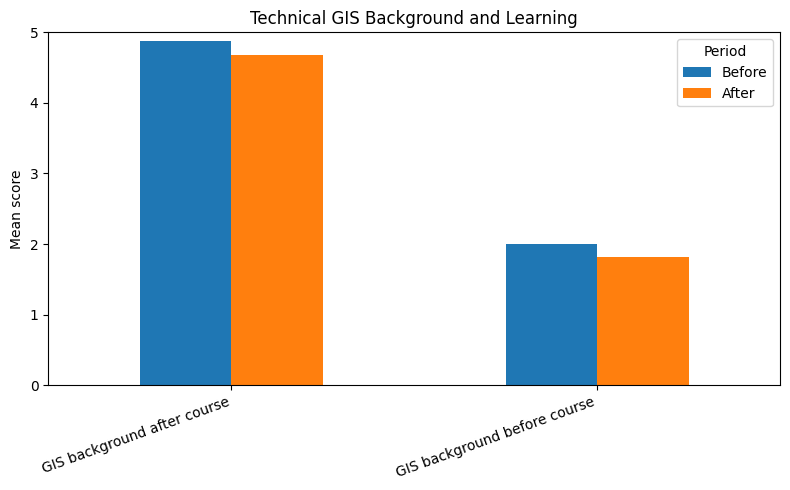

In [59]:
tech_summary = []
for col, label in [('Q1.7', 'GIS background before course'), ('Q1.8', 'GIS background after course')]:
    score_col = col + '_score'
    for period in ['Before', 'After']:
        values = num.loc[num['period'] == period, score_col].dropna()
        tech_summary.append({
            'Measure': label,
            'Period': period,
            'n': len(values),
            'Mean': round(values.mean(), 3),
            'SD': round(values.std(ddof=1), 3)
        })

tech_table = pd.DataFrame(tech_summary)
display(tech_table)
save_table_to_excel(tech_table, 'technical_learning_summary')

tech_plot = tech_table.pivot(index='Measure', columns='Period', values='Mean')[['Before', 'After']]
ax = tech_plot.plot(kind='bar', figsize=(8, 5))
ax.set_title('Technical GIS Background and Learning')
ax.set_ylabel('Mean score')
ax.set_xlabel('')
ax.set_ylim(0, 5)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'technical_learning_bar.png', dpi=300, bbox_inches='tight')
plt.show()

## demographic comparisons

exploratory (if required for building the context)

In [60]:
status_summary = num.groupby(['period', 'Q1.6'])['Overall Inclusive GIS Curriculum Score'].agg(['count', 'mean', 'std']).reset_index()
status_summary['mean'] = status_summary['mean'].round(3)
status_summary['std'] = status_summary['std'].round(3)
display(status_summary)
save_table_to_excel(status_summary, 'overall_score_by_student_status')

background_summary = num.groupby(['period', 'Q1.3'])['Overall Inclusive GIS Curriculum Score'].agg(['count', 'mean', 'std']).reset_index()
background_summary['mean'] = background_summary['mean'].round(3)
background_summary['std'] = background_summary['std'].round(3)
display(background_summary)
save_table_to_excel(background_summary, 'overall_score_by_academic_background')

,period,Q1.6,count,mean,std
0,After,Domestic,7,3.253,0.452
1,After,International,15,3.229,0.551
2,Before,Domestic,1,3.270,NaN
3,Before,International,7,3.673,0.486


,period,Q1.3,count,mean,std
0,After,Engineering,9,3.321,0.492
1,After,Other,7,3.280,0.279
2,After,Social Science,3,3.393,0.830
3,After,Urban Planning,3,2.727,0.622
4,Before,Engineering,2,3.790,0.438
5,Before,Other,5,3.572,0.568
6,Before,Urban Planning,1,3.540,NaN


c:\Users\snigd\AppData\Local\Programs\Python\Python310\lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


## question-level means

to refer back

In [61]:
question_labels = {
    'Q2.2': 'Curriculum represents diverse perspectives',
    'Q2.3': 'Balanced gender diversity',
    'Q2.4': 'Balanced diverse demographics',
    'Q2.5': 'Balanced geographic regions',
    'Q2.7': 'Understanding social/cultural issues',
    'Q3.2': 'Case studies from diverse groups',
    'Q3.3': 'Case studies on gender diversity',
    'Q3.5': 'Case studies on diverse geographies',
    'Q3.6': 'Case studies on diverse demographics',
    'Q3.7': 'Case studies on social/cultural issues',
    'Q4.2': 'Materials on diverse groups',
    'Q4.3': 'Materials on gender diversity',
    'Q4.4': 'Materials on diverse geographies',
    'Q4.5': 'Materials on diverse demographics',
    'Q5.3': 'Diverse perspectives in lectures',
    'Q5.4': 'Diverse perspectives in demos',
    'Q5.5': 'Diverse perspectives in homework',
    'Q5.6': 'Diverse perspectives in final projects',
    'Q5.7': 'Connect GIS skills to societal problems'
}

question_rows = []
for q, label in question_labels.items():
    score_col = q + '_score'
    for period in ['Before', 'After']:
        values = num.loc[num['period'] == period, score_col].dropna()
        question_rows.append({
            'Question': q,
            'Label': label,
            'Period': period,
            'n': len(values),
            'Mean': round(values.mean(), 3),
            'SD': round(values.std(ddof=1), 3)
        })

question_table = pd.DataFrame(question_rows)
display(question_table)
save_table_to_excel(question_table, 'question_level_means')

,Question,Label,Period,n,Mean,SD
0,Q2.2,Curriculum represents diverse perspectives,Before,8,3.375,0.744
1,Q2.2,Curriculum represents diverse perspectives,After,22,3.045,0.950
2,Q2.3,Balanced gender diversity,Before,8,3.500,0.535
3,Q2.3,Balanced gender diversity,After,22,2.909,0.868
4,Q2.4,Balanced diverse demographics,Before,8,3.750,0.463
5,Q2.4,Balanced diverse demographics,After,22,3.000,0.816
6,Q2.5,Balanced geographic regions,Before,8,3.250,1.035
7,Q2.5,Balanced geographic regions,After,22,3.136,0.889
8,Q2.7,Understanding social/cultural issues,Before,8,3.250,0.463
9,Q2.7,Understanding social/cultural issues,After,22,3.318,0.716


c:\Users\snigd\AppData\Local\Programs\Python\Python310\lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


## Likert distribution plots

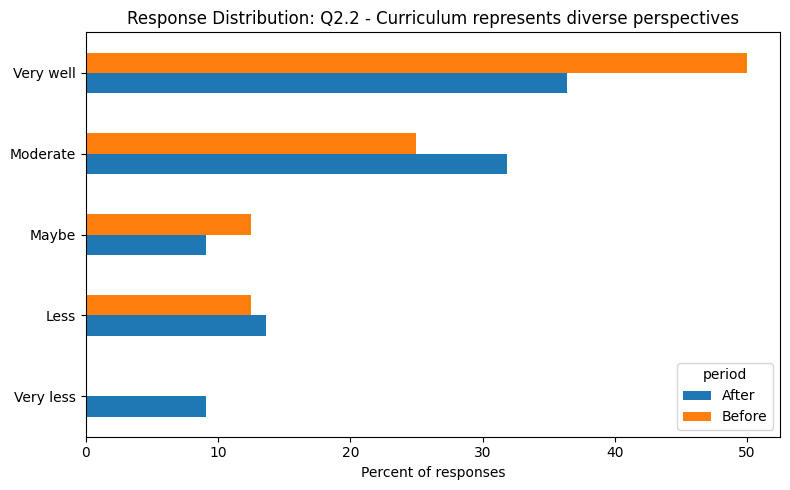

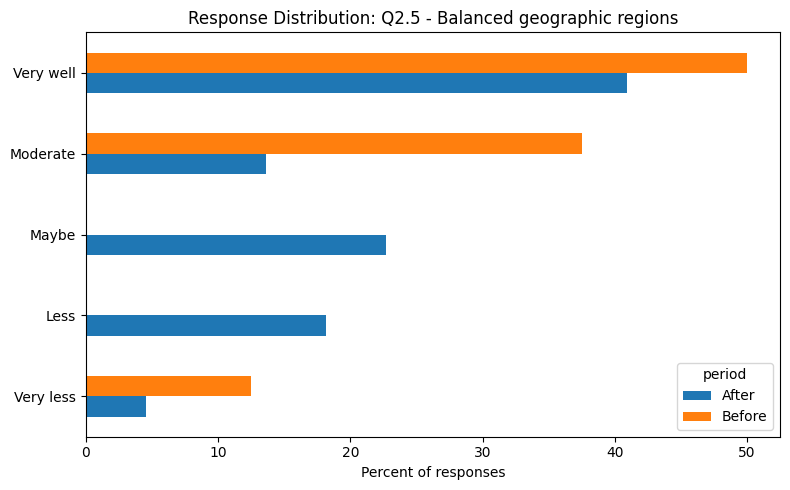

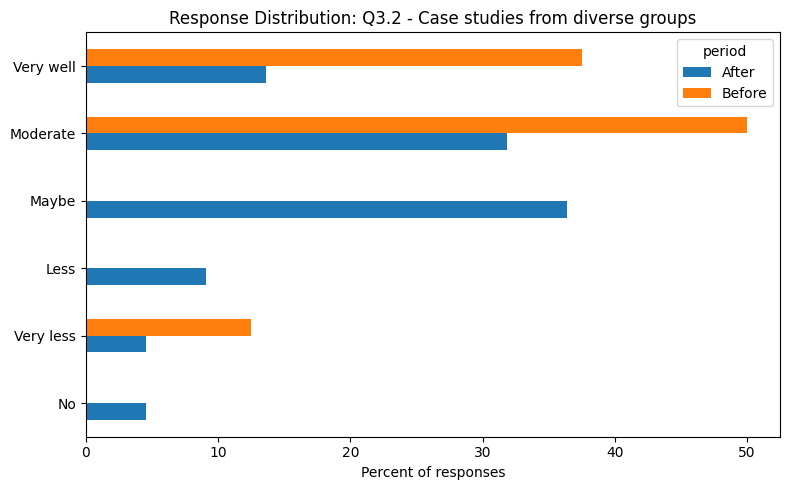

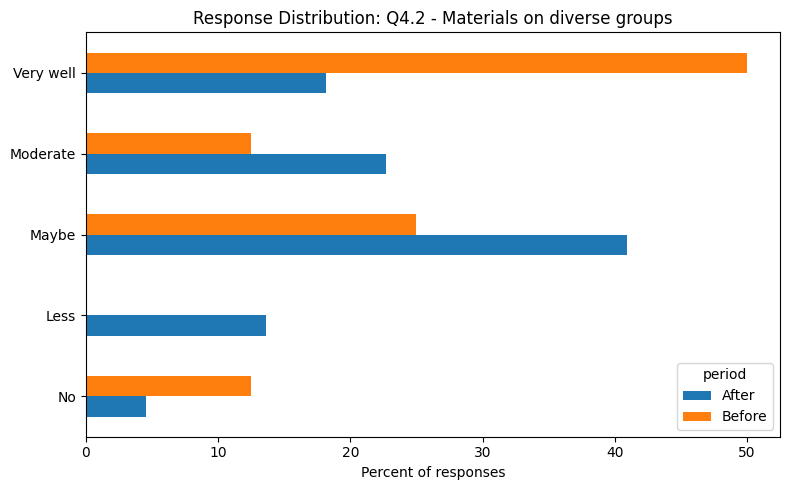

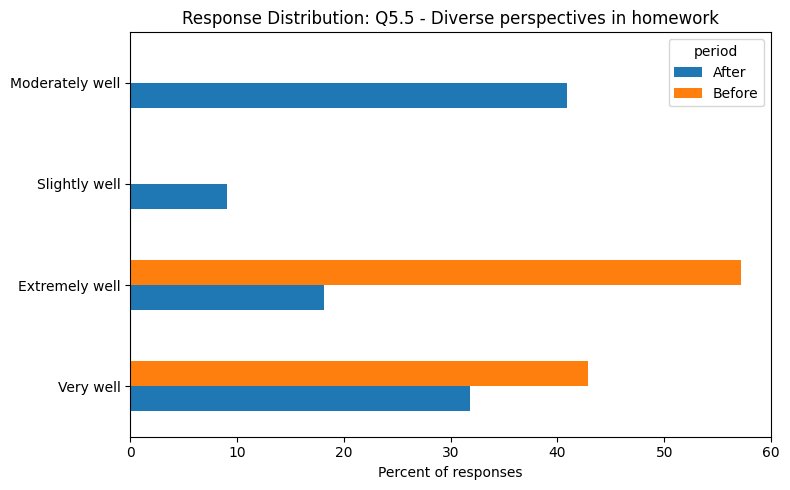

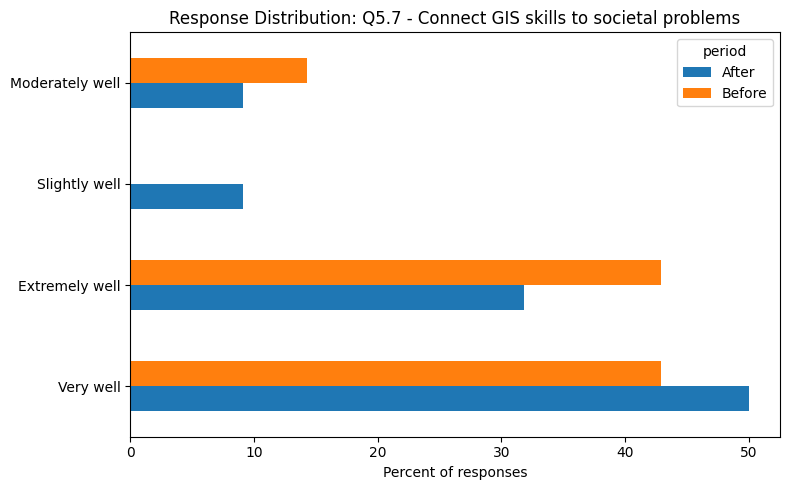

In [62]:
ordered_responses = ['No', 'Very less', 'Less', 'Maybe', 'Moderate', 'Very well', 'Extremely well', 'Extreamly well',
                     'Not well at all', 'Slightly well', 'Moderately well']

selected_questions = ['Q2.2', 'Q2.5', 'Q3.2', 'Q4.2', 'Q5.5', 'Q5.7']

for q in selected_questions:
    dist = (
        df.groupby('period')[q]
        .value_counts(normalize=True)
        .rename('percent')
        .reset_index()
    )
    dist['percent'] = dist['percent'] * 100
    dist_pivot = dist.pivot(index=q, columns='period', values='percent').fillna(0)
    
    dist_pivot = dist_pivot.loc[[r for r in ordered_responses if r in dist_pivot.index]]
    
    ax = dist_pivot.plot(kind='barh', figsize=(8, 5))
    ax.set_title(f'Response Distribution: {q} - {question_labels.get(q, q)}')
    ax.set_xlabel('Percent of responses')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'likert_distribution_{q}.png', dpi=300, bbox_inches='tight')
    plt.show()

## Qualitative categorization

In [63]:
for col in open_ended_cols:
    print('' + col)
    display(df[['period', col]].dropna())

Q6.2


,period,Q6.2
1,Before,no
2,Before,some interesting and actionable GIS application to tackle real-world challenge
5,Before,"Most students in class has no background in GIS, thus its natural for the professor to demonstrate the tools and dem..."
10,After,When you said 'diverse' does that mean diverse in American context? I kind of confused. But I think it covers East a...
11,After,"Most of the data we worked with was based in the US, and tended to be very urban-focused."
13,After,"More examples and datasets from diverse regions, not only U.S.-based cities.\n"
14,After,The current GIS curriculum is sufficient for its inclusivity.
15,After,Maybe Different countries in the activities would be helpful in addressing issues in different countries.
16,After,I think the curriculum could include more examples that highlight diverse social and environmental issues faced by d...
18,After,Using data from diverse industries/looking at case studies of how employers use GIS. Making maps of regions outside ...


Q6.3


,period,Q6.3
1,Before,no
5,Before,"A lot of the students in the GIS class are international students, who lack their knowledge of American history and ..."
10,After,"I want to say to explore more from outside the US, but the data is really limited (I have tried it for my country lol)"
11,After,"Having more rural communities, and countries beyond the US would be very useful; including a focus on alternative me..."
13,After,"Rural areas, Global South communities, and low-income neighborhoods that face environmental and infrastructure chall..."
14,After,Maybe some foreign countries such as France or Canada.
15,After,International students or international communities.
16,After,"It would be great to see more case studies from underrepresented regions like Southeast Asia, Africa, and Indigenous..."
18,After,"Women, youth, low-income neighborhoods, other countries"
20,After,"I think looking at more international cities would be helpful, though I understand that is difficult with language b..."


Q6.4


,period,Q6.4
1,Before,no
10,After,-
13,After,"Open-source global datasets (e.g., UN SDG data, WorldPop, OpenStreetMap) and case studies focused on underserved reg..."
14,After,"Datasets from public transit such as MTA, MBTA, SEPTA, WMATA, etc."
15,After,Datasets of different countries that are available in the internet.
16,After,"I would love to see more open-source global datasets, like Humanitarian Data Exchange or UN spatial data, added to g..."
22,After,no
24,After,"stop and frisk, mayor's office to ENDGBV datasets"
27,After,"I would really like to work more with raster data and real-world imagery, such as drone photos or satellite images. ..."
30,After,Datasets from Google earth engine


,Theme,Period,Count,Percent
0,Global South / international contexts,Before,1,12.5
1,Global South / international contexts,After,7,31.8
2,Rural communities,Before,0,0.0
3,Rural communities,After,3,13.6
4,Indigenous communities,Before,0,0.0
5,Indigenous communities,After,2,9.1
6,Accessibility / disability,Before,0,0.0
7,Accessibility / disability,After,1,4.5
8,Environmental justice / climate,Before,0,0.0
9,Environmental justice / climate,After,2,9.1


c:\Users\snigd\AppData\Local\Programs\Python\Python310\lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


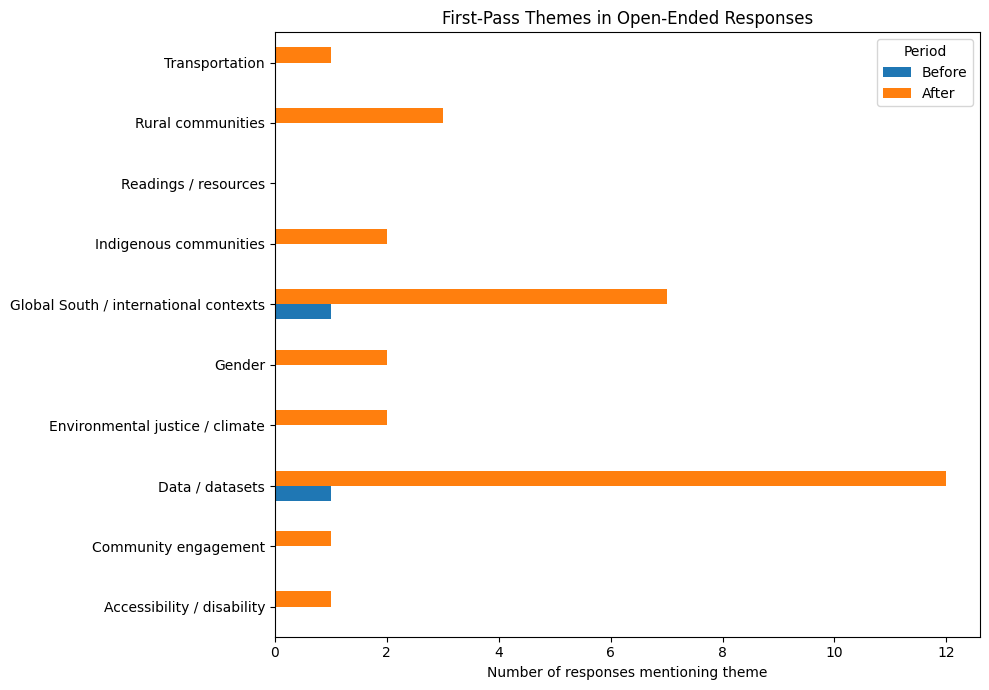

In [64]:
# Simple keyword dictionary for first-pass thematic coding
theme_keywords = {
    'Global South / international contexts': ['global south', 'international', 'india', 'africa', 'latin', 'asia', 'south asia', 'developing'],
    'Rural communities': ['rural'],
    'Indigenous communities': ['indigenous', 'native', 'tribal', 'first nations'],
    'Accessibility / disability': ['accessibility', 'disability', 'disabled', 'ada'],
    'Environmental justice / climate': ['environmental', 'climate', 'flood', 'pollution', 'green space'],
    'Gender': ['gender', 'female', 'women'],
    'Transportation': ['transportation', 'transit', 'subway', 'mobility'],
    'Data / datasets': ['data', 'dataset', 'datasets'],
    'Readings / resources': ['reading', 'readings', 'resource', 'resources', 'paper', 'article'],
    'Community engagement': ['community', 'participatory', 'engagement']
}

open_text = df[open_ended_cols].fillna('').agg(' '.join, axis=1).str.lower()

theme_rows = []
for theme, keywords in theme_keywords.items():
    for period in ['Before', 'After']:
        texts = open_text[df['period'] == period]
        count = texts.apply(lambda x: any(k in x for k in keywords)).sum()
        theme_rows.append({
            'Theme': theme,
            'Period': period,
            'Count': int(count),
            'Percent': round(count / len(texts) * 100, 1) if len(texts) > 0 else np.nan
        })

theme_table = pd.DataFrame(theme_rows)
display(theme_table)
save_table_to_excel(theme_table, 'open_ended_theme_counts_first_pass')

# Plot theme counts
theme_plot = theme_table.pivot(index='Theme', columns='Period', values='Count').fillna(0)
theme_plot = theme_plot[['Before', 'After']]
ax = theme_plot.plot(kind='barh', figsize=(10, 7))
ax.set_title('First-Pass Themes in Open-Ended Responses')
ax.set_xlabel('Number of responses mentioning theme')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'open_ended_theme_counts.png', dpi=300, bbox_inches='tight')
plt.show()

In [65]:
analysis_path = TABLE_DIR / 'analysis_ready_survey_with_indices.csv'
num.to_csv(analysis_path, index=False)
save_table_to_excel(num, 'analysis_ready_survey_with_indices')

c:\Users\snigd\AppData\Local\Programs\Python\Python310\lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")
